# Grayscale to Color Image Conversion with PyTorch

This notebook implements a neural network to convert grayscale images to color using PyTorch, following the same architecture as the TensorFlow/Keras version.

## 1. Import Required Libraries

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import random
from skimage.color import rgb2lab, lab2rgb, rgb2gray
from skimage.io import imsave, imread

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## 2. Load and Preprocess Image Data

In [7]:
# Load the image
image = imread('woman.jpg')
image = np.array(image, dtype=float)

image = image[:,:,:3]  # Ensure image has 3 channels (RGB)- remove opacity channel if present
print(f"Original image shape: {image.shape}")
print(f"Image data type: {image.dtype}")

Original image shape: (400, 400, 3)
Image data type: float64


## 3. Convert Image to LAB Color Space

In [8]:
# Convert RGB to LAB color space
lab_image = rgb2lab(1.0/255 * image)

# Separate L channel (grayscale) and AB channels (color)
L_channel = lab_image[:, :, 0]  # Lightness channel
AB_channels = lab_image[:, :, 1:]  # A and B color channels

# Normalize AB channels
AB_channels = AB_channels / 128.0

# Convert to PyTorch tensors and add batch dimension
# PyTorch expects (batch, channels, height, width) format
X = torch.FloatTensor(L_channel).unsqueeze(0).unsqueeze(0)  # Shape: (1, 1, 400, 400)
Y = torch.FloatTensor(AB_channels).permute(2, 0, 1).unsqueeze(0)  # Shape: (1, 2, 400, 400)

print(f"Input (L channel) shape: {X.shape}")
print(f"Target (AB channels) shape: {Y.shape}")
print(f"L channel range: [{X.min():.2f}, {X.max():.2f}]")
print(f"AB channels range: [{Y.min():.2f}, {Y.max():.2f}]")

# Move to device
X = X.to(device)
Y = Y.to(device)

Input (L channel) shape: torch.Size([1, 1, 400, 400])
Target (AB channels) shape: torch.Size([1, 2, 400, 400])
L channel range: [1.29, 90.49]
AB channels range: [-0.14, 0.31]


## 4. Define PyTorch CNN Model Architecture

In [9]:
class ColorizationCNN(nn.Module):
    def __init__(self):
        super(ColorizationCNN, self).__init__()
        
        # Encoder (downsampling path)
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, stride=2, padding=1)
        self.conv2 = nn.Conv2d(8, 8, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(8, 16, kernel_size=3, stride=1, padding=1)
        self.conv4 = nn.Conv2d(16, 16, kernel_size=3, stride=2, padding=1)
        self.conv5 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.conv6 = nn.Conv2d(32, 32, kernel_size=3, stride=2, padding=1)
        
        # Decoder (upsampling path)
        self.upsample1 = nn.Upsample(scale_factor=2, mode='nearest')
        self.conv7 = nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1)
        self.upsample2 = nn.Upsample(scale_factor=2, mode='nearest')
        self.conv8 = nn.Conv2d(32, 16, kernel_size=3, stride=1, padding=1)
        self.upsample3 = nn.Upsample(scale_factor=2, mode='nearest')
        self.conv9 = nn.Conv2d(16, 2, kernel_size=3, stride=1, padding=1)
        
    def forward(self, x):
        # Encoder
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = F.relu(self.conv5(x))
        x = F.relu(self.conv6(x))
        
        # Decoder
        x = self.upsample1(x)
        x = F.relu(self.conv7(x))
        x = self.upsample2(x)
        x = F.relu(self.conv8(x))
        x = self.upsample3(x)
        x = torch.tanh(self.conv9(x))  # tanh activation for final output
        
        return x

# Create model instance
model = ColorizationCNN().to(device)

# Print model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Model Architecture:")
print(model)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Model Architecture:
ColorizationCNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (conv2): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (conv5): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv6): Conv2d(32, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (upsample1): Upsample(scale_factor=2.0, mode='nearest')
  (conv7): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (upsample2): Upsample(scale_factor=2.0, mode='nearest')
  (conv8): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (upsample3): Upsample(scale_factor=2.0, mode='nearest')
  (conv9): Conv2d(16, 2, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)

Total parameters: 32,202
Trainable parameters: 32,202


## 5. Setup Training Configuration

In [10]:
# Training configuration
criterion = nn.MSELoss()  # Mean Squared Error loss
optimizer = optim.RMSprop(model.parameters(), lr=0.001)  # RMSprop optimizer

# Training parameters
num_epochs = 1000
batch_size = 1

print(f"Loss function: {criterion}")
print(f"Optimizer: {optimizer}")
print(f"Number of epochs: {num_epochs}")
print(f"Batch size: {batch_size}")

Loss function: MSELoss()
Optimizer: RMSprop (
Parameter Group 0
    alpha: 0.99
    capturable: False
    centered: False
    differentiable: False
    eps: 1e-08
    foreach: None
    lr: 0.001
    maximize: False
    momentum: 0
    weight_decay: 0
)
Number of epochs: 1000
Batch size: 1


## 6. Train the Model

In [ ]:
# Training loop
model.train()
losses = []

print("Starting training...")
for epoch in range(num_epochs):
    # Forward pass
    optimizer.zero_grad()
    output = model(X)
    loss = criterion(output, Y)
    
    # Backward pass
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    # Print progress every 100 epochs
    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.6f}')

print("Training completed!")
print(f"Final loss: {losses[-1]:.6f}")

Starting training...
Epoch [100/1000], Loss: 0.003946
Epoch [100/1000], Loss: 0.003946
Epoch [200/1000], Loss: 0.003856
Epoch [200/1000], Loss: 0.003856
Epoch [300/1000], Loss: 0.002429
Epoch [300/1000], Loss: 0.002429
Epoch [400/1000], Loss: 0.002863
Epoch [400/1000], Loss: 0.002863
Epoch [500/1000], Loss: 0.002107
Epoch [500/1000], Loss: 0.002107
Epoch [600/1000], Loss: 0.001347
Epoch [600/1000], Loss: 0.001347
Epoch [700/1000], Loss: 0.001063
Epoch [700/1000], Loss: 0.001063
Epoch [800/1000], Loss: 0.000744
Epoch [800/1000], Loss: 0.000744
Epoch [900/1000], Loss: 0.001619
Epoch [900/1000], Loss: 0.001619
Epoch [1000/1000], Loss: 0.000612
Training completed!
Final loss: 0.000612
Epoch [1000/1000], Loss: 0.000612
Training completed!
Final loss: 0.000612


ModuleNotFoundError: No module named 'matplotlib'

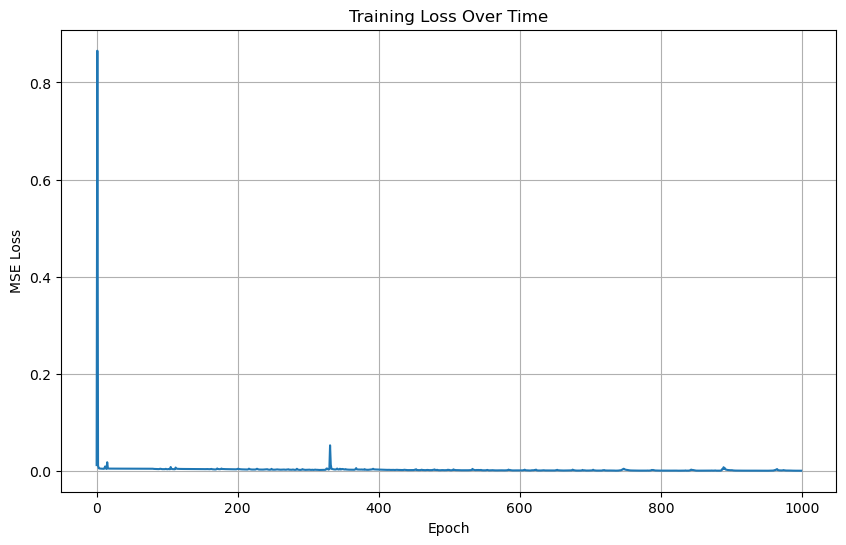

In [15]:
# Plot training loss
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title('Training Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True)
plt.show()

## 7. Generate Colorized Output

In [16]:
# Evaluate the model
model.eval()
with torch.no_grad():
    # Calculate final loss
    final_output = model(X)
    final_loss = criterion(final_output, Y)
    print(f"Final evaluation loss: {final_loss.item():.6f}")
    
    # Generate prediction
    predicted_ab = model(X)
    
    # Convert back to numpy and move to CPU
    predicted_ab_np = predicted_ab.cpu().numpy()
    X_np = X.cpu().numpy()
    
    # Scale AB channels back to original range
    predicted_ab_np *= 128.0
    
    print(f"Predicted AB shape: {predicted_ab_np.shape}")
    print(f"Predicted AB range: [{predicted_ab_np.min():.2f}, {predicted_ab_np.max():.2f}]")

Final evaluation loss: 0.000648
Predicted AB shape: (1, 2, 400, 400)
Predicted AB range: [-22.19, 42.54]


## 8. Convert Results and Save Images

Saved colorized result as 'pytorch_img_result.png'
Saved grayscale version as 'pytorch_img_gray_version.png'


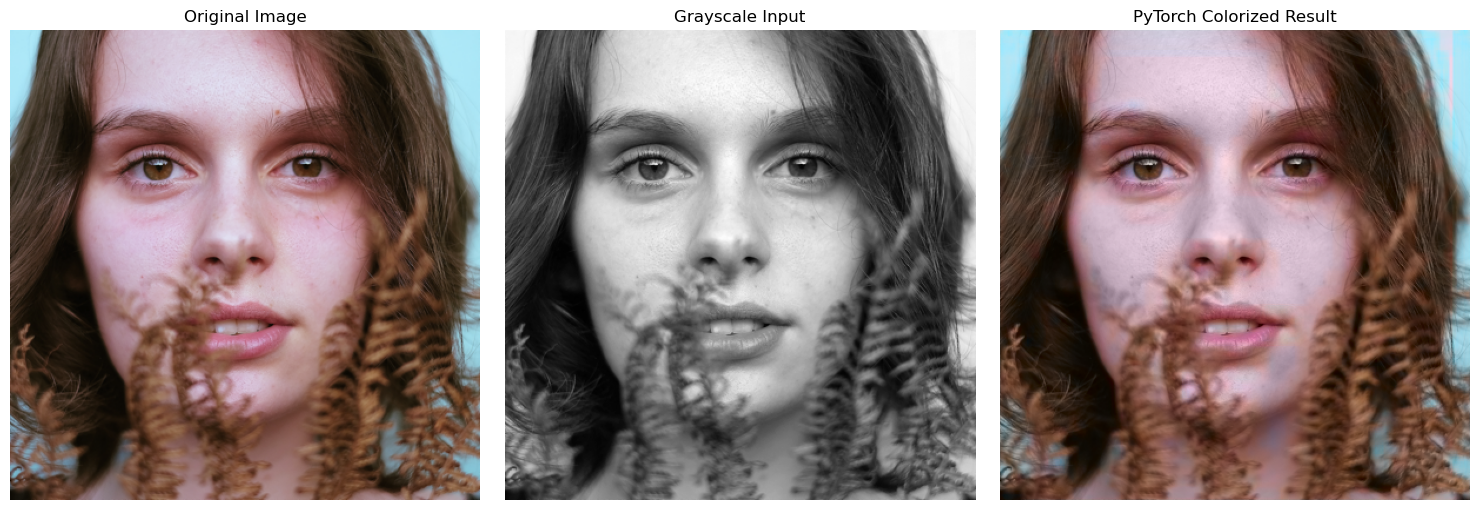


Colorization completed successfully!


In [17]:
# Combine L channel with predicted AB channels
cur = np.zeros((400, 400, 3))
cur[:, :, 0] = X_np[0, 0, :, :]  # L channel
cur[:, :, 1:] = predicted_ab_np[0].transpose(1, 2, 0)  # AB channels

# Convert from Lab to RGB
rgb_result = lab2rgb(cur)

# Convert to uint8 format (0-255 range) for saving
rgb_result_uint8 = (rgb_result * 255).astype(np.uint8)

# Save the colorized result
imsave("pytorch_img_result.png", rgb_result_uint8)
print("Saved colorized result as 'pytorch_img_result.png'")

# Create and save grayscale version
gray_result = rgb2gray(rgb_result)
gray_result_uint8 = (gray_result * 255).astype(np.uint8)
imsave("pytorch_img_gray_version.png", gray_result_uint8)
print("Saved grayscale version as 'pytorch_img_gray_version.png'")

# Display results using matplotlib
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

# Original image (use RGB version)
plt.subplot(1, 3, 1)
if image.shape[2] == 4:
    plt.imshow(image[:, :, :3].astype(np.uint8))
else:
    plt.imshow(image.astype(np.uint8))
plt.title('Original Image')
plt.axis('off')

# Grayscale input
plt.subplot(1, 3, 2)
plt.imshow(gray_result_uint8, cmap='gray')
plt.title('Grayscale Input')
plt.axis('off')

# Colorized result
plt.subplot(1, 3, 3)
plt.imshow(rgb_result_uint8)
plt.title('PyTorch Colorized Result')
plt.axis('off')

plt.tight_layout()
plt.show()

print("\nColorization completed successfully!")

# Try on another image

Man image shape: (400, 400, 3)
Man image data type: float64
Man image value range: [0.00, 212.00]
Man input (L channel) shape: torch.Size([1, 1, 400, 400])
Man target (AB channels) shape: torch.Size([1, 2, 400, 400])
Man image evaluation loss: 0.006102
Saved man colorized result as 'pytorch_man_result.png'


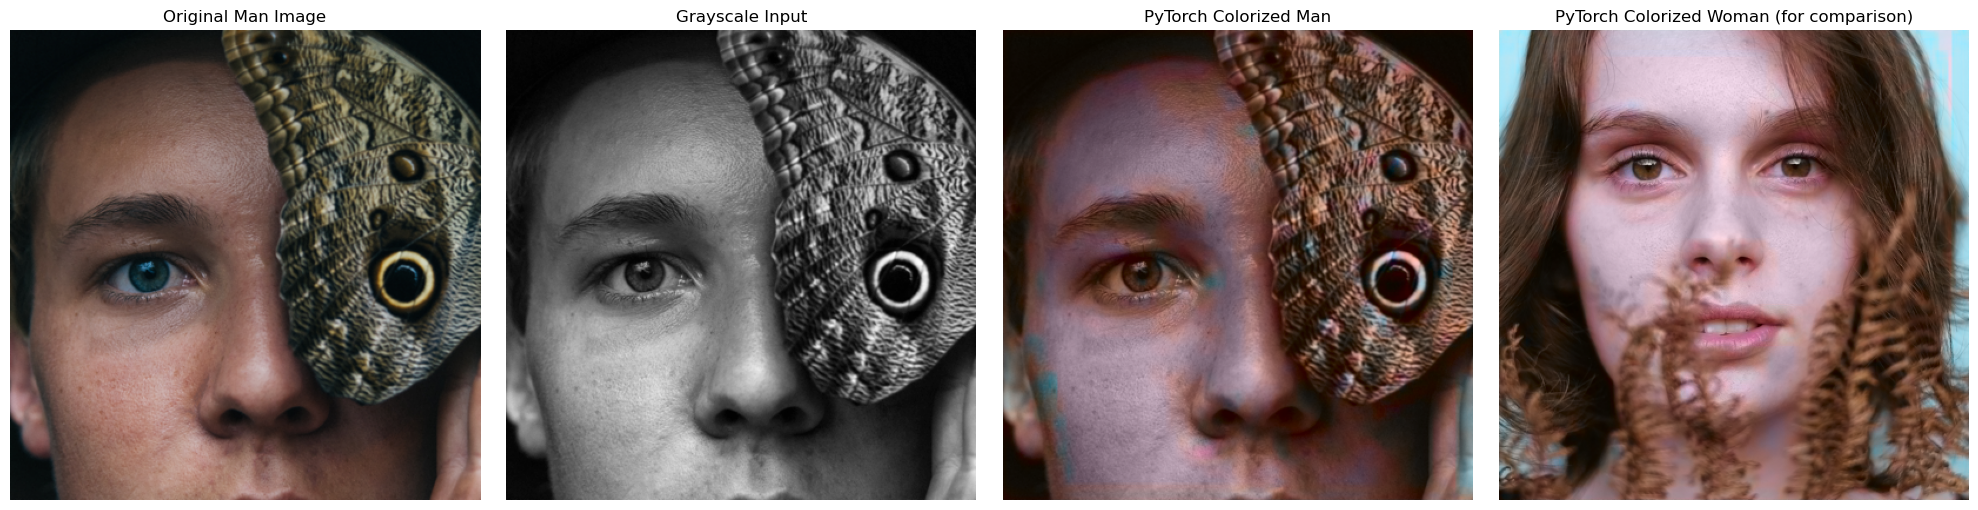


Man image colorization completed!
Man image evaluation loss: 0.006102
Woman image evaluation loss: 0.000648


In [18]:
# Load and preprocess man.jpg image
try:
    man_image = imread('man.jpg')
    man_image = np.array(man_image, dtype=float)
    
    # Ensure image has 3 channels (RGB) - remove alpha channel if present
    if len(man_image.shape) == 3 and man_image.shape[2] == 4:
        man_image = man_image[:, :, :3]
    
    print(f"Man image shape: {man_image.shape}")
    print(f"Man image data type: {man_image.dtype}")
    print(f"Man image value range: [{man_image.min():.2f}, {man_image.max():.2f}]")
    
    # Convert RGB to LAB color space
    man_lab_image = rgb2lab(1.0/255 * man_image)
    
    # Separate L channel (grayscale) and AB channels (color)
    man_L_channel = man_lab_image[:, :, 0]
    man_AB_channels = man_lab_image[:, :, 1:]
    
    # Normalize AB channels
    man_AB_channels = man_AB_channels / 128.0
    
    # Convert to PyTorch tensors
    man_X = torch.FloatTensor(man_L_channel).unsqueeze(0).unsqueeze(0).to(device)
    man_Y = torch.FloatTensor(man_AB_channels).permute(2, 0, 1).unsqueeze(0).to(device)
    
    print(f"Man input (L channel) shape: {man_X.shape}")
    print(f"Man target (AB channels) shape: {man_Y.shape}")
    
    # Evaluate the model on man.jpg
    model.eval()
    with torch.no_grad():
        # Generate prediction for man.jpg
        man_predicted_ab = model(man_X)
        
        # Calculate loss on man.jpg (if we had ground truth colors)
        man_loss = criterion(man_predicted_ab, man_Y)
        print(f"Man image evaluation loss: {man_loss.item():.6f}")
        
        # Convert back to numpy
        man_predicted_ab_np = man_predicted_ab.cpu().numpy()
        man_X_np = man_X.cpu().numpy()
        
        # Scale AB channels back to original range
        man_predicted_ab_np *= 128.0
        
        # Combine L channel with predicted AB channels
        man_cur = np.zeros((man_image.shape[0], man_image.shape[1], 3))
        man_cur[:, :, 0] = man_X_np[0, 0, :, :]  # L channel
        man_cur[:, :, 1:] = man_predicted_ab_np[0].transpose(1, 2, 0)  # AB channels
        
        # Convert from Lab to RGB
        man_rgb_result = lab2rgb(man_cur)
        
        # Convert to uint8 format
        man_rgb_result_uint8 = (man_rgb_result * 255).astype(np.uint8)
        
        # Save the colorized result
        imsave("pytorch_man_result.png", man_rgb_result_uint8)
        print("Saved man colorized result as 'pytorch_man_result.png'")
        
        # Create grayscale version
        man_gray_result = rgb2gray(man_rgb_result)
        man_gray_result_uint8 = (man_gray_result * 255).astype(np.uint8)
        
        # Display comparison
        plt.figure(figsize=(20, 5))
        
        # Original man image
        plt.subplot(1, 4, 1)
        plt.imshow(man_image.astype(np.uint8))
        plt.title('Original Man Image')
        plt.axis('off')
        
        # Grayscale input
        plt.subplot(1, 4, 2)
        plt.imshow(man_gray_result_uint8, cmap='gray')
        plt.title('Grayscale Input')
        plt.axis('off')
        
        # Colorized result
        plt.subplot(1, 4, 3)
        plt.imshow(man_rgb_result_uint8)
        plt.title('PyTorch Colorized Man')
        plt.axis('off')
        
        # Side by side comparison with woman result
        plt.subplot(1, 4, 4)
        plt.imshow(rgb_result_uint8)
        plt.title('PyTorch Colorized Woman (for comparison)')
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()
        
        print(f"\nMan image colorization completed!")
        print(f"Man image evaluation loss: {man_loss.item():.6f}")
        print(f"Woman image evaluation loss: {final_loss.item():.6f}")

except FileNotFoundError:
    print("Error: man.jpg file not found in the current directory.")
    print("Please make sure man.jpg exists in the same folder as this notebook.")
except Exception as e:
    print(f"Error processing man.jpg: {str(e)}")